# 02 — Mean Reversion with Bollinger Bands

The opposite philosophy to trend-following: when a price moves far from its recent average, bet on it coming back.

Bollinger Bands define a dynamic channel:

$$\text{upper} = \mu_{t} + n \cdot \sigma_{t}, \quad \text{lower} = \mu_{t} - n \cdot \sigma_{t}$$

where $\mu_t$ and $\sigma_t$ are the rolling mean and standard deviation over a window of $w$ days.

**Signal rule:**
- price < lower band → long (expect reversion up)
- price > upper band → short (expect reversion down)
- price inside bands → flat

Works best in range-bound, low-trend markets. Can be painful in strong trending regimes — shorting a rising stock because it looks 'expensive' is a classic mean-reversion trap.

In [9]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import load_prices
from backtester import run
from metrics import summary, sharpe_ratio
from strategies.mean_reversion import signals

In [10]:
ticker = 'SW'
start  = '2018-01-01'
end    = '2023-01-01'

prices = load_prices(ticker, start, end)

window = 30
n_std  = 1.5

sig    = signals(prices, window=window, n_std=n_std)
result = run(prices, sig, initial_capital=10_000, transaction_cost=0.001)

print(f"Performance ({ticker}, {start} — {end})")
print(f"  Bollinger Bands: window={window}, n_std={n_std}")
print()
summary(result['equity'], result['strategy_ret'])

Performance (SW, 2018-01-01 — 2023-01-01)
  Bollinger Bands: window=30, n_std=1.5

  Annualized return     : 27.82%
  Sharpe ratio          : 1.16
  Max drawdown          : -20.42%
  Calmar ratio          : 1.36
  Win rate              : 30.90%
  Total trades          : 301


{'Annualized return': '27.82%',
 'Sharpe ratio': '1.16',
 'Max drawdown': '-20.42%',
 'Calmar ratio': '1.36',
 'Win rate': '30.90%',
 'Total trades': 301}

## Price with Bollinger Bands and trade signals

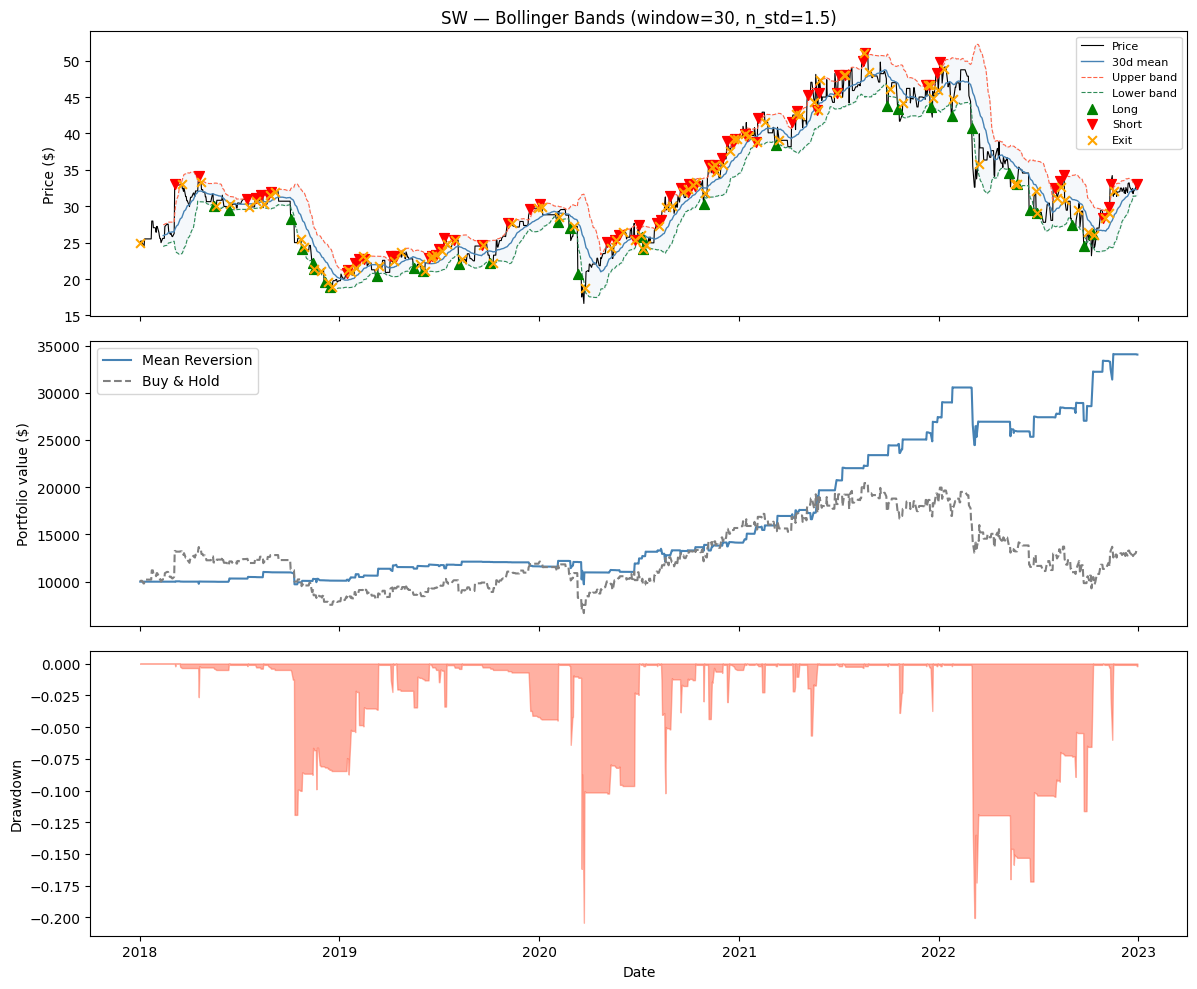

In [11]:
rolling_mean = prices.rolling(window).mean()
rolling_std  = prices.rolling(window).std()
upper = rolling_mean + n_std * rolling_std
lower = rolling_mean - n_std * rolling_std

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# price + bands
axes[0].plot(prices.index, prices,        color='black',     linewidth=0.8, label='Price')
axes[0].plot(prices.index, rolling_mean,  color='steelblue', linewidth=1.0, label=f'{window}d mean')
axes[0].plot(prices.index, upper,         color='tomato',    linewidth=0.8, linestyle='--', label='Upper band')
axes[0].plot(prices.index, lower,         color='seagreen',  linewidth=0.8, linestyle='--', label='Lower band')
axes[0].fill_between(prices.index, upper, lower, alpha=0.05, color='steelblue')

buys  = result[(result['trade'] == 1) & (result['position'] ==  1)]
shorts = result[(result['trade'] == 1) & (result['position'] == -1)]
exits = result[(result['trade'] == 1) & (result['position'] ==  0)]

axes[0].scatter(buys.index,   buys['price'],   marker='^', color='green',  s=50, zorder=5, label='Long')
axes[0].scatter(shorts.index, shorts['price'], marker='v', color='red',    s=50, zorder=5, label='Short')
axes[0].scatter(exits.index,  exits['price'],  marker='x', color='orange', s=40, zorder=5, label='Exit')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=8)
axes[0].set_title(f'{ticker} — Bollinger Bands (window={window}, n_std={n_std})')

# equity curves
axes[1].plot(result.index, result['equity'],    label='Mean Reversion', color='steelblue')
axes[1].plot(result.index, result['bh_equity'], label='Buy & Hold',     color='gray', linestyle='--')
axes[1].set_ylabel('Portfolio value ($)')
axes[1].legend()

# drawdown
rolling_max = result['equity'].cummax()
drawdown    = (result['equity'] - rolling_max) / rolling_max
axes[2].fill_between(result.index, drawdown, 0, color='tomato', alpha=0.5)
axes[2].set_ylabel('Drawdown')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Parameter sweep: window vs. n_std

Wider bands → fewer signals, each with higher statistical significance. Narrower bands → more trades, more noise.

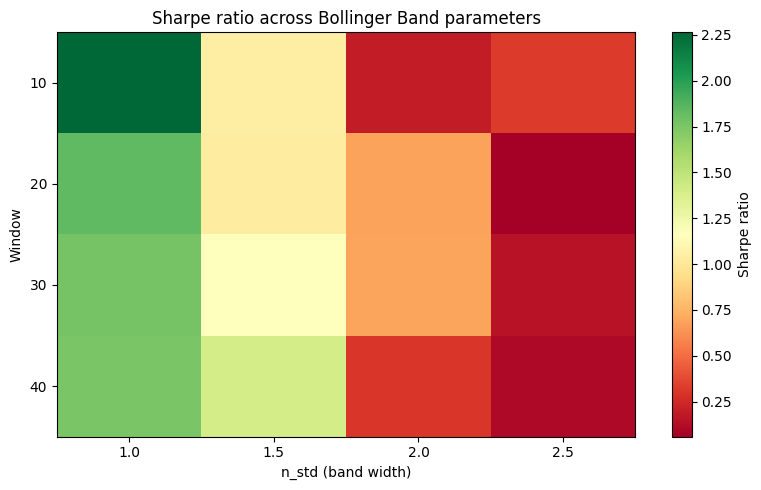

In [12]:
windows  = [10, 20, 30, 40]
n_stds   = [1.0, 1.5, 2.0, 2.5]

sharpe_grid = pd.DataFrame(index=windows, columns=n_stds, dtype=float)

for w in windows:
    for n in n_stds:
        sig = signals(prices, window=w, n_std=n)
        res = run(prices, sig)
        sharpe_grid.loc[w, n] = sharpe_ratio(res['strategy_ret'])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(sharpe_grid.values.astype(float), cmap='RdYlGn', aspect='auto')
fig.colorbar(im, ax=ax, label='Sharpe ratio')
ax.set_xticks(range(len(n_stds)))
ax.set_yticks(range(len(windows)))
ax.set_xticklabels(n_stds)
ax.set_yticklabels(windows)
ax.set_xlabel('n_std (band width)')
ax.set_ylabel('Window')
ax.set_title('Sharpe ratio across Bollinger Band parameters')
plt.tight_layout()
plt.show()